# Does It Matter *How* You Ask a Judge to Score?

### A hands-on tutorial on scoring formats in LLM-judge data curation

You have 10,000 candidate instruction–response pairs and budget to fine-tune on
2,000. No human annotators. So you do the standard thing: ask a language model
to score every candidate, keep the best, and train on those.

Somewhere in building that pipeline you make a decision that almost nobody
reports. You have to choose **how to ask the judge for its opinion**:

- "Reply `ACCEPT` or `REJECT`."
- "Rate this 1–5."
- "Rate this 0–100."
- "Is this better or worse than a reference response?"

Everyone picks one, early, on grounds of convenience, and then never mentions it
again. Papers name the *judge model* and omit the *response format* entirely.
The implicit assumption is that the format is a cosmetic detail — a capable
judge will produce sensible scores on whatever scale you hand it.

**This notebook shows why that assumption is wrong**, and gives you a toy
laboratory to poke at the mechanism yourself.

---

### What you'll build

A simulated curation pipeline over 250 prompts × 4 candidate responses, where —
unlike in real life — **you know the true quality of every candidate**. That
lets you measure precisely how much quality each scoring format throws away.

### What you'll learn

| § | Idea |
|---|---|
| 3 | The five formats are the *same judge* under five different quantizers |
| 4 | **Ties** are the mechanism: a coarse format can't order within its accepted class |
| 5 | Nominal granularity ≠ effective granularity (and a sampling trap that fools people) |
| 6 | Two reasonable agreement metrics rank the formats in **opposite** orders |
| 7 | Selection quality: what each format actually hands to the trainer |
| 8 | Format explains far more variance than judge *model* choice |
| 9 | How a broken output parser silently manufactures a null result |

### Requirements

`numpy`, `pandas`, `scipy`, `matplotlib`. **No API key, no GPU, no network.**
Runs in about 20 seconds.

> **On simulation.** We simulate the judge rather than call one. That is a
> deliberate teaching choice, not a shortcut: in a simulation you have access to
> ground-truth quality, which you never have with a real judge, so you can see
> exactly what each format costs you. Section 8 is explicit about which
> conclusions the simulation *illustrates* versus which ones require real
> experiments to *establish*.

## 1. Setup

Everything is seeded, so your numbers will match the commentary exactly. Change
`SEED` at the end when you want to check that a finding isn't a fluke.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

SEED = 0
N_PROMPTS = 250      # prompts in the candidate pool
K = 4                # candidate responses per prompt
rng = np.random.default_rng(SEED)

pd.set_option("display.width", 100)
pd.set_option("display.float_format", lambda v: f"{v:8.3f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
print(f"pool: {N_PROMPTS} prompts x {K} candidates = {N_PROMPTS*K} candidates")

pool: 250 prompts x 4 candidates = 1000 candidates


## 2. A candidate pool with known true quality

Real quality has **two** components, and keeping them separate turns out to
matter enormously:

- **Between-prompt variation.** Some prompts just draw better answers than
  others — they're easier, or better specified.
- **Within-prompt variation.** Among the 4 answers to *one* prompt, some are
  better than others.

Curation only ever consumes the **within-prompt** part. When you pick the best
of 4 responses to a prompt, differences between *prompts* are irrelevant — you
are ranking inside a single prompt's slate.

This distinction is the reason a judge can look excellent by one measure and be
useless for selection. A global correlation against reference labels is
dominated by the between-prompt spread, which is the easy part and the part
selection never uses. Keep it in mind for §6.

In [2]:
prompt_baseline = rng.normal(0.0, 1.00, N_PROMPTS)      # between-prompt
within_offset   = rng.normal(0.0, 0.70, (N_PROMPTS, K)) # within-prompt
true_q = prompt_baseline[:, None] + within_offset       # (N_PROMPTS, K)

var_between = prompt_baseline.var()
var_within  = within_offset.var()
print(f"between-prompt variance : {var_between:.3f}  <- selection never uses this")
print(f"within-prompt  variance : {var_within:.3f}  <- selection uses ONLY this")
print(f"share of total that selection can act on: "
      f"{var_within/(var_between+var_within):.1%}\n")

pool = pd.DataFrame({
    "prompt": np.repeat(np.arange(N_PROMPTS), K),
    "cand":   np.tile(np.arange(K), N_PROMPTS),
    "true_q": true_q.ravel(),
})
print(pool.head(8).to_string(index=False))

between-prompt variance : 1.035  <- selection never uses this
within-prompt  variance : 0.463  <- selection uses ONLY this
share of total that selection can act on: 30.9%

 prompt  cand   true_q
      0     0    0.267
      0     1    0.099
      0     2    0.872
      0     3   -0.519
      1     0    0.431
      1     1    0.465
      1     2   -0.599
      1     3   -0.018


## 3. One judge, five formats

Here is the core of the experiment, and the thing to hold onto:

> **The judge forms the same internal opinion every time. The only thing that
> changes is the container we make it pour that opinion into.**

We model the judge as seeing true quality through noise:

$$\text{obs} = q_{\text{true}} + \varepsilon,\qquad \varepsilon \sim \mathcal{N}(0,\sigma^2)$$

`σ` is the judge's *competence* — a better judge has smaller σ. Then each
scoring format is a **quantizer** applied to that one `obs` value. Binary
crushes it to 1 bit. Likert keeps about 2.3 bits. And so on.

Every format below receives *identical* `obs` input. Any difference in what
they select is caused purely by the shape of the container.

In [3]:
def observe(truth, sigma, rng):
    """The judge's noisy read on true quality. Same for every format."""
    return truth + rng.normal(0.0, sigma, truth.shape)


def fmt_binary(obs, rng, bias=0.0, strict=0.0):
    """ACCEPT / REJECT -> {0, 1}, at a FIXED internal standard.

    The threshold is an absolute value, not a pool quantile: a real judge
    carries its own bar for 'acceptable' rather than re-normalising to whatever
    pool you hand it. `strict` shifts that bar -- a harsh grader vs a lenient
    one. Note this is a property of the JUDGE, not of the format (see §8).
    """
    return ((obs - strict) > 0.2).astype(float)


def fmt_likert5(obs, rng, bias=0.0, strict=0.0):
    """1-5 rating -> 5 levels at fixed cut points."""
    return np.digitize(obs - strict, [-1.03, -0.31, 0.31, 1.03]).astype(float)


def fmt_numeric100(obs, rng, bias=0.0, strict=0.0):
    """0-100 rating.

    Two behaviours real judges reliably show on wide scales, both modelled here:
      * grade inflation  -> the exponent pushes mass toward the top;
      * round-number bias -> most answers land on multiples of 5, only
        sometimes on an arbitrary integer.
    Together these are why a nominally 100-point scale is not a 100-point scale.
    """
    p = 1.0 / (1.0 + np.exp(-(obs - strict - 0.2)))
    raw = 100 * p ** 0.55
    prefers_round = rng.random(obs.shape) < 0.88
    return np.where(prefers_round, np.round(raw / 5) * 5, np.round(raw))


def fmt_anchored(obs, rng, bias=0.0, strict=0.0):
    """Compare each candidate to that prompt's median response, 5-level verdict.

    `bias` is a position/order artifact: a judge's tendency to favour whichever
    slot the candidate sits in. It is NOT a property of the responses.
    """
    # `strict` cancels here: both sides shift together. Comparative formats
    # are immune to grader strictness, which pointwise formats are not.
    anchor = np.median(obs, axis=1, keepdims=True)
    margin = obs - anchor + bias
    return np.digitize(margin, [-0.75, -0.25, 0.25, 0.75]).astype(float)


def fmt_tournament(obs, rng, bias=0.0, strict=0.0):
    """All C(4,2)=6 within-prompt pairs, aggregated Bradley-Terry style.

    Each candidate appears in both slots across its matchups, so slot bias
    cancels in aggregate -- this is the control that isolates `bias` in §8.
    """
    n, k = obs.shape
    d = obs[:, :, None] - obs[:, None, :]        # pairwise margins
    w = 1.0 / (1.0 + np.exp(-d))                 # logistic win prob
    # w[p,i,i] is sigmoid(0)=0.5; subtracting it drops the self-comparison.
    return (w.sum(axis=2) - 0.5) / (k - 1)


FORMATS = {"binary": fmt_binary, "likert_5": fmt_likert5,
           "numeric_100": fmt_numeric100, "anchored": fmt_anchored,
           "tournament": fmt_tournament}

SIGMA = 0.45
obs = observe(true_q, SIGMA, np.random.default_rng(SEED + 1))
scores = {name: f(obs, rng) for name, f in FORMATS.items()}

demo = pd.DataFrame({"true_q": true_q[0], "judge_obs": obs[0],
                     **{n: s[0] for n, s in scores.items()}})
print("The 4 candidates for prompt 0, scored five ways:\n")
print(demo.to_string(index=True))

The 4 candidates for prompt 0, scored five ways:

    true_q  judge_obs   binary  likert_5  numeric_100  anchored  tournament
0    0.267      0.423    1.000     3.000       70.000     2.000       0.555
1    0.099      0.468    1.000     3.000       75.000     2.000       0.568
2    0.872      1.021    1.000     3.000       80.000     3.000       0.724
3   -0.519     -1.106    0.000     0.000       45.000     0.000       0.152


Look at the `binary` column. The judge privately ranked these four candidates —
that ordering is sitting right there in `judge_obs` — and then the format threw
most of it away. Any two candidates sharing a `1` are now, as far as the
pipeline is concerned, **indistinguishable**.

That is not a rounding error. It is the whole story, and §4 measures it.

## 4. Mechanism 1 — ties, and why they cost you

A curation pipeline never consumes scores as *measurements*. It consumes them as
an **ordering**: it repeatedly asks "which of these is better?" and keeps the
winner.

When two candidates carry the same score, the pipeline cannot answer. It breaks
the tie **arbitrarily** — in our harness, and in most real ones, with a coin
flip.

So the useful summary of a format is its **tie probability**: the chance that two
randomly drawn candidates receive identical scores. Where that probability is
high, the judge has been consulted but has effectively abstained.

             tie_prob  distinct_values  top1_decided_by_coinflip
format                                                          
binary          0.511                2                     0.760
likert_5        0.202                5                     0.456
numeric_100     0.052               70                     0.160
anchored        0.221                5                     0.272
tournament      0.000             1000                     0.000


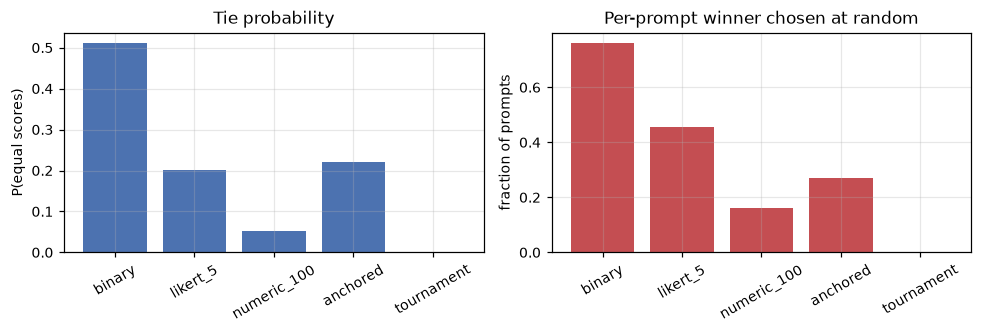

In [4]:
def tie_prob(x):
    """P(two randomly drawn candidates get identical scores)."""
    v = x.ravel()
    _, counts = np.unique(v, return_counts=True)
    n = v.size
    return (counts * (counts - 1)).sum() / (n * (n - 1))


def tie_rate_at_top(x):
    """How often the per-prompt winner is decided by coin flip, not judgment."""
    return float(np.mean([(row == row.max()).sum() > 1 for row in x]))


tab = pd.DataFrame([{
    "format": n,
    "tie_prob": tie_prob(s),
    "distinct_values": len(np.unique(s)),
    "top1_decided_by_coinflip": tie_rate_at_top(s),
} for n, s in scores.items()]).set_index("format")
print(tab.to_string())

fig, ax = plt.subplots(1, 2, figsize=(9, 3.1))
ax[0].bar(tab.index, tab["tie_prob"], color="#4C72B0")
ax[0].set_title("Tie probability"); ax[0].set_ylabel("P(equal scores)")
ax[1].bar(tab.index, tab["top1_decided_by_coinflip"], color="#C44E52")
ax[1].set_title("Per-prompt winner chosen at random")
ax[1].set_ylabel("fraction of prompts")
for a in ax:
    a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

The right-hand panel is the one that should worry you.

Under **binary**, the "best" response to a prompt is picked by coin flip most of
the time. The judge was asked, the judge answered, and the answer contained no
information about the decision that was actually being made. Under
**tournament**, that essentially never happens.

Notice this has nothing to do with the judge being weak. `σ` is identical across
all five columns. The judge knew the answer; the format prevented it from saying so.

## 5. Mechanism 2 — nominal granularity is not effective granularity

A 0–100 scale offers 20× the resolution of a 1–5 scale. Does it deliver it?

numeric_100 touched 70 of 101 possible values
top-5 most frequent values hold 36.2% of all mass
tie probability  numeric_100 = 0.052   vs likert_5 = 0.202
skew of numeric_100 = -0.29 (negative = grade inflation, mass piled at the top)


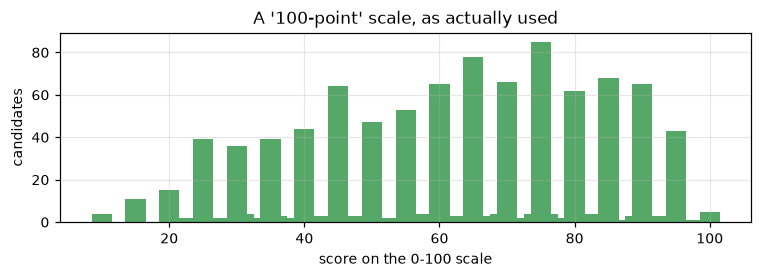

In [5]:
n100 = scores["numeric_100"]
vals, cnts = np.unique(n100, return_counts=True)
print(f"numeric_100 touched {len(vals)} of 101 possible values")
print(f"top-5 most frequent values hold "
      f"{np.sort(cnts)[-5:].sum()/cnts.sum():.1%} of all mass")
print(f"tie probability  numeric_100 = {tie_prob(n100):.3f}"
      f"   vs likert_5 = {tie_prob(scores['likert_5']):.3f}")
print(f"skew of numeric_100 = {stats.skew(n100.ravel()):+.2f} "
      f"(negative = grade inflation, mass piled at the top)")

plt.figure(figsize=(7, 2.6))
plt.bar(vals, cnts, width=3.0, color="#55A868")
plt.xlabel("score on the 0-100 scale"); plt.ylabel("candidates")
plt.title("A '100-point' scale, as actually used")
plt.tight_layout(); plt.show()

The scale is nominally 101 values wide. It is being operated at a small
fraction of that: most of the mass sits on a handful of round numbers near the
top, and the tie probability lands far closer to Likert-5's than the 20x
improvement the scale width advertises.

**A reported scale width tells a reader almost nothing.** Effective granularity
is an empirical property of the judge's behaviour, and it has to be measured.

### A sampling trap worth knowing about

"Distinct values touched" is a seductive statistic and it is **sample-size
dependent**. Score 500 candidates and you will touch fewer distinct values than
if you score 5,000 — from the identical judge and the identical distribution.

So if you ever compare two judges on this metric, and they scored pools of
different sizes, you can manufacture a difference out of nothing. Here is the
effect, measured:

In [6]:
full = n100.ravel()
for frac in (0.05, 0.1, 0.25, 0.5, 1.0):
    m = max(2, int(len(full) * frac))
    draws = [len(np.unique(rng.choice(full, m, replace=False))) for _ in range(200)]
    print(f"  n={m:>4}  distinct values = {np.mean(draws):5.1f} "
          f"+/- {np.std(draws):.1f}   (tie prob {tie_prob(rng.choice(full, m, replace=False)):.3f})")
print("\ndistinct-value counts grow with n; tie probability does not.")
print("=> compare judges on TIE PROBABILITY, which is sample-size invariant.")

  n=  50  distinct values =  20.8 +/- 2.2   (tie prob 0.038)
  n= 100  distinct values =  27.9 +/- 2.7   (tie prob 0.045)
  n= 250  distinct values =  41.0 +/- 3.0   (tie prob 0.053)
  n= 500  distinct values =  56.0 +/- 2.7   (tie prob 0.051)
  n=1000  distinct values =  70.0 +/- 0.0   (tie prob 0.052)

distinct-value counts grow with n; tie probability does not.
=> compare judges on TIE PROBABILITY, which is sample-size invariant.


That last line is the practical takeaway, and it is a real trap: the
sample-size-invariant statistic (tie probability) and the sample-size-dependent
one (distinct values) look equally reasonable side by side in a table.

## 6. Mechanism 3 — two sensible metrics, opposite answers

You want to sanity-check that your scoring format agrees with a trusted
reference ranking. Two obvious ways:

1. **Within-prompt rank correlation** — across the 4 responses to a prompt, does
   the format order them like the reference does? (Kendall's τ, which adjusts
   for ties.)
2. **Top-1 agreement** — is the format's *highest-scored* response the same one
   the reference ranks first, after the coin-flip tie-breaking your pipeline
   actually performs?

Both are defensible. Both are used. Watch what happens.

**One realism detail that matters here.** Your reference ranking is not
continuous ground truth — it is itself a coarse annotation, typically an LLM's
integer score on a 1–10 scale. So we build `ref_score` by quantizing true
quality into 10 levels. The tie structure *of the reference* turns out to be
part of the story, because Kendall's τ-b corrects for ties on both sides.

In [7]:
# The reference is a coarse annotation (integer 1-10), not continuous truth.
ref_score = np.clip(np.round(5.5 + 2.0 * true_q), 1, 10)
print(f"reference: {len(np.unique(ref_score)):.0f} distinct levels, "
      f"tie prob {tie_prob(ref_score):.3f}")


def within_prompt_tau(s, truth):
    t = [stats.kendalltau(s[p], truth[p])[0] for p in range(s.shape[0])]
    return float(np.nanmean(t))


def top1_agreement(s, truth, rng):
    hits = 0
    for p in range(s.shape[0]):
        best = np.flatnonzero(s[p] == s[p].max())
        hits += int(rng.choice(best) == np.argmax(truth[p]))
    return hits / s.shape[0]


g = np.random.default_rng(SEED + 7)
cmp = pd.DataFrame([{
    "format": n,
    "within_prompt_tau": within_prompt_tau(s, ref_score),
    "top1_agreement": top1_agreement(s, ref_score, g),
    "tie_prob": tie_prob(s),
} for n, s in scores.items()]).set_index("format")
cmp["rank_by_tau"] = cmp["within_prompt_tau"].rank(ascending=False).astype(int)
cmp["rank_by_top1"] = cmp["top1_agreement"].rank(ascending=False).astype(int)
print(cmp.to_string())

rho = stats.spearmanr(cmp["rank_by_tau"], cmp["rank_by_top1"]).statistic
print(f"\nSpearman between the two metric rankings: {rho:+.2f}")
print("  (+1 = metrics agree perfectly, 0 = unrelated, -1 = exact inversion)\n")
for f in cmp.index:
    a, b = cmp.loc[f, "rank_by_tau"], cmp.loc[f, "rank_by_top1"]
    if abs(a - b) >= 2:
        print(f"  {f:<12} ranked #{a} by within-prompt tau, but #{b} by top-1")

reference: 10 distinct levels, tie prob 0.117


             within_prompt_tau  top1_agreement  tie_prob  rank_by_tau  rank_by_top1
format                                                                             
binary                   0.663           0.424     0.511            5             5
likert_5                 0.712           0.564     0.202            2             4
numeric_100              0.703           0.620     0.052            3             2
anchored                 0.739           0.592     0.221            1             3
tournament               0.694           0.628     0.000            4             1

Spearman between the two metric rankings: +0.10
  (+1 = metrics agree perfectly, 0 = unrelated, -1 = exact inversion)

  likert_5     ranked #2 by within-prompt tau, but #4 by top-1
  anchored     ranked #1 by within-prompt tau, but #3 by top-1
  tournament   ranked #4 by within-prompt tau, but #1 by top-1


### Why they disagree

The two rankings are only weakly related, and some formats move several places
between them. Watch **tournament** especially: mediocre by within-prompt τ,
first by top-1 agreement.

The reason is tie handling. Kendall's τ-b **adjusts for ties on both sides**, so
a format earns credit for whatever coarse-but-real structure it does capture
across the full slate. That is genuine information and τ rewards it.

But at the **selection frontier** — the one place the pipeline actually needs an
answer — what matters is whether the top-scored response is *uniquely* top. A
format with heavy tie mass hands that decision to a coin flip no matter how
sensibly it ordered everything else. Tournament orders the slate no better than
the pointwise formats, yet it essentially never ties at the top, so it wins the
decision that gets made.

**Neither metric is wrong.** They measure different things and they support
different conclusions about the same data, so which format a practitioner
declares "validated" is decided by which metric they happened to compute. §7
shows which of the two actually predicts downstream quality.

> In the real study the inversion is sharper still: binary scored *best* of the
> pointwise formats on within-prompt τ and *worst* on top-1 agreement — so the
> metric you pick doesn't just reshuffle the ranking, it can invert your
> recommendation outright.

## 7. What each format actually hands to the trainer

Now run the real curation policy:

1. **Within each prompt**, keep the highest-scored response (ties → coin flip).
2. **Globally**, rank the survivors by score and keep the top `r` fraction.

Then ask the only question that matters: *how good is the data that came out?*
We can answer exactly, because we know `true_q`. Two reference points:

- **Oracle** — selection using true quality. The ceiling.
- **Random** — selection ignoring the judge entirely. The floor, and the honest
  baseline for "was consulting the judge worth anything?"

In [8]:
REPS = 25          # average over tie-break draws; a single draw is very noisy


def step1_pick(s, g):
    """Within-prompt top-1, ties broken at random."""
    return np.array([g.choice(np.flatnonzero(r == r.max())) for r in s])


def within_prompt_quality(s, truth, seed=0):
    """STEP 1 ONLY: how good is the per-prompt winner?"""
    n = s.shape[0]
    return float(np.mean([
        truth[np.arange(n), step1_pick(s, np.random.default_rng(seed + t))].mean()
        for t in range(REPS)]))


def selection_quality(s, truth, retention, seed=0):
    """STEP 1 + STEP 2: per-prompt winner, then keep the globally top-r."""
    n, vals = s.shape[0], []
    for t in range(REPS):
        g = np.random.default_rng(seed + t)
        picks = step1_pick(s, g)
        sel = s[np.arange(n), picks]
        keep = np.argsort(-(sel + 1e-9 * g.random(n)))[:max(1, int(n * retention))]
        vals.append(truth[keep, picks[keep]].mean())
    return float(np.mean(vals))


RETENTIONS = [0.10, 0.25, 0.50]
bench = dict(scores)
bench["oracle"] = true_q
bench["random"] = np.random.default_rng(SEED + 55).random(true_q.shape)

rows = []
for name, s in bench.items():
    row = {"format": name, "within_prompt_only": within_prompt_quality(s, true_q)}
    for r in RETENTIONS:
        row[r] = selection_quality(s, true_q, r)
    rows.append(row)

ORDER = ["oracle", "tournament", "numeric_100", "likert_5",
         "anchored", "binary", "random"]
full = pd.DataFrame(rows).set_index("format").loc[ORDER]
res = full[RETENTIONS]
print("Mean TRUE quality of the curated training set:\n")
print(full.to_string())

frac = ((res - res.loc["random"]) / (res.loc["oracle"] - res.loc["random"]))
print("\nShare of the achievable oracle gain captured (global selection):\n")
print((frac * 100).round(1).to_string())

Mean TRUE quality of the curated training set:

             within_prompt_only    0.100    0.250    0.500
format                                                    
oracle                    0.667    2.636    2.120    1.551
tournament                0.560    1.120    0.717    0.632
numeric_100               0.540    2.202    1.853    1.360
likert_5                  0.474    1.373    1.394    1.265
anchored                  0.545    0.664    0.659    0.646
binary                    0.274    0.824    0.841    0.837
random                    0.019    0.046    0.084    0.122

Share of the achievable oracle gain captured (global selection):

               0.100    0.250    0.500
format                                
oracle       100.000  100.000  100.000
tournament    41.400   31.100   35.700
numeric_100   83.300   86.900   86.700
likert_5      51.200   64.400   80.000
anchored      23.800   28.200   36.600
binary        30.100   37.200   50.000
random         0.000    0.000    0.000


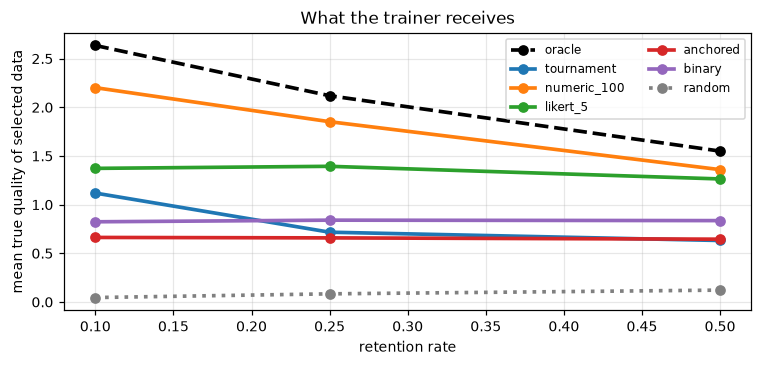

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.4))
for name in res.index:
    style = dict(lw=2.4, marker="o")
    if name == "oracle":
        style.update(color="black", ls="--")
    elif name == "random":
        style.update(color="grey", ls=":")
    ax.plot(RETENTIONS, res.loc[name], label=name, **style)
ax.set_xlabel("retention rate"); ax.set_ylabel("mean true quality of selected data")
ax.set_title("What the trainer receives")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

Read the "share of achievable gain" table. That is the number a practitioner
actually cares about: of the improvement perfect selection would have bought
you, how much did this format deliver?

Binary sits far below the finer-grained formats — not because the judge was
worse (σ was identical throughout) but because binary discarded the ordering
before the pipeline could use it. The ranking here tracks the **top-1
agreement** column from §6, not the **within-prompt τ** column. A practitioner
who validated their setup with rank correlation would have concluded binary was
the *best* pointwise format, and been wrong in the direction that costs money.

### Why tournament wins step 1 and loses step 2

Compare the `within_prompt_only` column against the retention columns.
Tournament is at or near the top on within-prompt selection — no surprise, it
has by far the lowest tie probability — and yet it falls back once the global
step runs.

The reason is worth understanding, because it is a genuine property of
comparative formats and not an artifact. A tournament score is a candidate's
strength *relative to the others answering the same prompt*. Every prompt's
slate gets scored on roughly the same 0–1 range, whether that prompt drew four
brilliant answers or four terrible ones. So when step 2 ranks survivors
**across** prompts, a comparative score carries almost no information about
which prompts were good in the first place.

Pointwise formats are the mirror image: worse at ordering within a prompt,
but their scores are on a shared absolute scale, so they rank across prompts
just fine. **Comparative formats trade between-prompt calibration for
within-prompt discrimination.** Which trade is right depends entirely on
whether your pipeline's decisions are within-prompt, across-prompt, or both —
and a curation pipeline that filters globally is doing both.

> **In the real study**, this selected data is then used to LoRA-fine-tune 66
> models whose outputs are scored by a separate judge. This notebook stops at
> selection quality, which is the quantity fine-tuning consumes — it does not
> simulate training.

## 8. Format versus judge model — which matters more?

Everyone reports the judge model. Almost nobody reports the format. If you had
to document only one, which is the bigger lever?

We run a 5 formats × 2 judges grid. The two judges differ in competence (σ) and
in their **slot bias** — a tendency to favour whichever position a response
occupies, which is a property of the protocol rather than of the responses.

In [10]:
JUDGES = {"judge_A (harsh grader, favours anchor slot)":    dict(sigma=0.55, bias=-0.35, strict=+0.45),
          "judge_B (lenient grader, favours candidate slot)": dict(sigma=0.30, bias=+0.40, strict=-0.30)}

grid = []
for jname, cfg in JUDGES.items():
    o = observe(true_q, cfg["sigma"], np.random.default_rng(SEED + 11))
    for fname, f in FORMATS.items():
        s = f(o, rng, bias=cfg["bias"], strict=cfg["strict"])
        g = np.random.default_rng(SEED + 13)
        grid.append({"judge": jname, "format": fname,
                     "tie_prob": tie_prob(s),
                     "top1_agreement": top1_agreement(s, true_q, g),
                     "skew": float(stats.skew(s.ravel()))})
G = pd.DataFrame(grid)
print(G.pivot(index="format", columns="judge", values="tie_prob").to_string())

judge        judge_A (harsh grader, favours anchor slot)  judge_B (lenient grader, favours candidate slot)
format                                                                                                    
anchored                                           0.243                                             0.268
binary                                             0.576                                             0.501
likert_5                                           0.226                                             0.207
numeric_100                                        0.049                                             0.062
tournament                                         0.000                                             0.000


In [11]:
def two_way(metric):
    """Variance of `metric` split into format / judge / residual."""
    M = G.pivot(index="format", columns="judge", values=metric).values
    grand = M.mean()
    ss_f = M.shape[1] * ((M.mean(axis=1) - grand) ** 2).sum()
    ss_j = M.shape[0] * ((M.mean(axis=0) - grand) ** 2).sum()
    ss_t = ((M - grand) ** 2).sum()
    return {"metric": metric, "format_%": 100 * ss_f / ss_t,
            "judge_%": 100 * ss_j / ss_t,
            "residual_%": 100 * (ss_t - ss_f - ss_j) / ss_t,
            "ratio_fmt_over_judge": ss_f / max(ss_j, 1e-12)}

print(pd.DataFrame([two_way("tie_prob"), two_way("top1_agreement")])
        .set_index("metric").to_string())

                format_%  judge_%  residual_%  ratio_fmt_over_judge
metric                                                             
tie_prob          99.040    0.092       0.868              1081.769
top1_agreement    89.893    6.184       3.923                14.536


On the properties that decide **which candidates a filter keeps**, the format
dominates the judge by a wide margin. A pipeline description that names the
model and omits the format has documented the smaller factor.

### The slot-bias artifact

Look at what `bias` does to the **anchored** format across the two judges:

In [12]:
sk = G.pivot(index="format", columns="judge", values="skew")
print(sk.to_string())
print("\nanchored  skew flips sign between judges on IDENTICAL data.")
print("tournament skew stays ~0 for both: each candidate occupies both slots,")
print("so the artifact cancels. Order control is what separates them.")

judge        judge_A (harsh grader, favours anchor slot)  judge_B (lenient grader, favours candidate slot)
format                                                                                                    
anchored                                           0.551                                            -0.656
binary                                             0.852                                            -0.100
likert_5                                           0.439                                            -0.253
numeric_100                                       -0.017                                            -0.441
tournament                                        -0.041                                            -0.035

anchored  skew flips sign between judges on IDENTICAL data.
tournament skew stays ~0 for both: each candidate occupies both slots,
so the artifact cancels. Order control is what separates them.


The anchored score distribution **reverses direction** depending only on which
model is reading the prompt. A genuine quality signal cannot do that. The
asymmetry is measuring the judge's slot preference, not the responses.

Tournament is the control that proves it: same comparative verdict scale, same
judges — but each candidate appears in *both* slots across its matchups, so the
bias cancels, and the skew sits at zero for both judges. **Order control is not
optional for comparative scoring.**

---

> ### What this simulation does and does not establish
>
> Be clear-eyed here. We *built* a simulator in which the format sets the
> quantizer and the judge sets the noise — so of course tie structure is
> format-dominated. The simulation demonstrates that **this mechanism produces
> these consequences**; it cannot tell you that real judges behave this way.
>
> That second part is an empirical claim and needs real experiments: score a
> real pool with real judges under each format and measure the same quantities.
> When you do, the pattern holds — which is the finding, and is what makes the
> mechanism above worth understanding.

## 9. The trap that eats results: your output parser

This section is not about scoring formats. It is about instrumentation, it cost
us a headline result on the real study, and it will happen to you.

You ask a judge to reply with exactly one of `A++ / A+ / TIE / B+ / B++`, and you
cap the response at 16 tokens. Reasonable. But the judge often replies:

> *"B is slightly better than response A. Here's why: — **Correctness**…"*

It stated a clear preference. Your regex finds no valid token, returns `None`,
and your evaluation code maps that to "tie". The verdict was there; the
instrument dropped it.

On the real run this affected **53.7% of 31,888 verdicts**. Below, we simulate
two systems that genuinely differ and watch the parser destroy the finding.

In [13]:
def evaluate(p_win, n_prompts, parse_fail, rng):
    """Judge n_prompts comparisons; a share `parse_fail` become unreadable -> 0.5."""
    out = (rng.random(n_prompts) < p_win).astype(float)
    out[rng.random(n_prompts) < parse_fail] = 0.5
    return out


P_GOOD, P_WEAK, N_EVAL, N_REPS = 0.52, 0.38, 300, 600

rows = []
for fail in [0.0, 0.2, 0.4, 0.535, 0.7, 0.8]:
    detected, deltas = 0, []
    for _ in range(N_REPS):
        g = np.random.default_rng(rng.integers(1 << 30))
        a = evaluate(P_GOOD, N_EVAL, fail, g)
        b = evaluate(P_WEAK, N_EVAL, fail, g)
        deltas.append(a.mean() - b.mean())
        detected += stats.ttest_rel(a, b).pvalue < 0.05
    rows.append({"parse_failure_rate": fail, "parse_rate": 1 - fail,
                 "observed_gap": np.mean(deltas),
                 "detection_rate": detected / N_REPS})
P = pd.DataFrame(rows)
print(f"true underlying gap = {P_GOOD - P_WEAK:.3f}\n")
print(P.to_string(index=False))

true underlying gap = 0.140

 parse_failure_rate  parse_rate  observed_gap  detection_rate
              0.000       1.000         0.140           0.928
              0.200       0.800         0.115           0.892
              0.400       0.600         0.083           0.740
              0.535       0.465         0.066           0.672
              0.700       0.300         0.042           0.472
              0.800       0.200         0.029           0.348


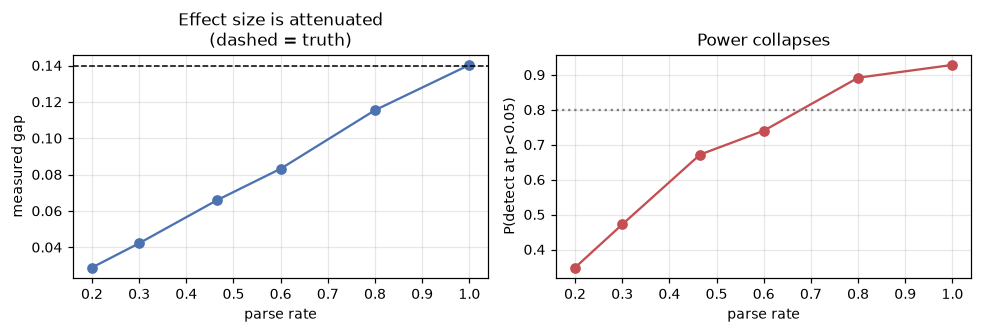

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.1))
ax[0].plot(P["parse_rate"], P["observed_gap"], marker="o", color="#4C72B0")
ax[0].axhline(P_GOOD - P_WEAK, ls="--", color="black", lw=1)
ax[0].set_xlabel("parse rate"); ax[0].set_ylabel("measured gap")
ax[0].set_title("Effect size is attenuated\n(dashed = truth)")
ax[1].plot(P["parse_rate"], P["detection_rate"], marker="o", color="#C44E52")
ax[1].axhline(0.8, ls=":", color="grey")
ax[1].set_xlabel("parse rate"); ax[1].set_ylabel("P(detect at p<0.05)")
ax[1].set_title("Power collapses")
plt.tight_layout(); plt.show()

The true difference never changed. Only the instrument did.

Two things worth internalising:

1. **Unparsed verdicts do not add noise — they add a pull toward 0.5.** Every
   failure is a vote for "no difference", so the measured gap shrinks
   systematically. This biases you toward the null.
2. **A null result from a low-resolution instrument means nothing.** "We found no
   difference" and "our instrument could not have detected one" look identical
   in a results table. Only the parse rate distinguishes them.

On the real study, re-parsing the *already-cached* judge outputs with a
prose-tolerant parser lifted the parse rate from 0.463 to 0.867 — no new API
calls — and a headline "these two are statistically indistinguishable" result
turned into a clear, significant difference. It had been an artifact all along.

> **Log your parse rate next to every judged metric.** If it isn't above ~0.9,
> fix the instrument before you interpret a single number.

## 10. Things to try

The pipeline is small enough to poke at. Some experiments that teach something:

1. **Make the judge perfect.** Set `SIGMA = 0.01` and re-run §7. Binary still
   underperforms — with *zero* judgment error. Proof that the loss comes from
   the format, not from judge mistakes.

2. **Add a Likert-3 and a Likert-10.** Where does the return on granularity flatten?
   Is more always better?

3. **Break tie-breaking deliberately.** In `curate`, replace the random choice
   with "always take the lowest index". Watch binary's numbers move — you are
   measuring how much of its performance was an accident of tie-break order.

4. **Vary the within/between split.** Raise `prompt_baseline`'s σ to 2.0 and drop
   `within_offset`'s to 0.3. Global correlation with truth goes *up* while
   selection quality goes *down*, because you have inflated the easy part that
   selection never touches.

5. **Give tournament a bigger slate.** Set `K = 8` (28 pairs). Comparative
   formats should pull further ahead — more pairs, better-estimated strengths.

6. **Sweep the parse rate in §9** against a *smaller* true gap. How good does
   your instrument have to be to detect a 2-point difference?

7. **Swap in a real judge.** Replace `observe()` with actual API calls that
   return each format's verdict, keeping everything downstream identical. That
   is exactly the step from this notebook to the real experiment — and the point
   at which you find out whether real judges tie the way this simulation assumes.

---

### The short version

- A scoring format is a **quantizer**, and quantization destroys ordering.
- Ordering is the only thing curation consumes, so tie structure is the
  mechanism that matters.
- **Nominal** scale width tells you nothing; measure **effective** granularity.
- Agreement metrics can rank formats oppositely — pick the one that matches
  the decision you actually make (top-1, not global correlation).
- Uncontrolled position bias in comparative formats can reverse between judges.
- Report the format, the effective granularity, the order control, **and the
  parse rate**. All four are free to compute and any of them can silently
  invalidate your results.